### Capacitated Vehicle Routing Problem (CVRP)

This variant considers that vehicles have a capacity $Q$ and that each customer $j$ has a demand $d_j$. The formulation is as follows:

$$
\begin{aligned}
\min \quad & \sum_{k \in K} \sum_{i \in N} \sum_{\substack{j \in N \\ j \ne i}} c_{ij} \cdot x_{ijk} \\
\text{s.t.} \quad
& \sum_{k \in K} \sum_{\substack{i \in N \\ i \ne j}} x_{ijk} = 1 && \forall j \in C \\
& \sum_{\substack{i \in N \\ i \ne h}} x_{ihk} = \sum_{\substack{j \in N \\ j \ne h}} x_{hjk} && \forall h \in N,\; \forall k \in K \\
& u_{ik} + d_j \cdot x_{ijk} \leq u_{jk} + Q \cdot (1 - x_{ijk}) && \forall i \ne j,\; i,j \in C,\; \forall k \in K \\
& u_{jk} \geq d_j,\quad u_{jk} \leq Q && \forall j \in C,\; \forall k \in K \\
& \sum_{j \in C} x_{0jk} = 1 && \forall k \in K \\
& \sum_{j \in C} x_{j0k} = 1 && \forall k \in K \\
& x_{ijk} \in \{0,1\} && \forall i,j \in N,\; i \ne j,\; \forall k \in K \\
& u_{ik} \in \mathbb{R} && \forall i \in N,\; \forall k \in K
\end{aligned}
$$


In [1]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
import itertools
import matplotlib.pyplot as plt
import math

In [2]:
# Coordinates: 0 is the depot
locations = {
    0: (50, 50),  # depot
    1: (20, 30),
    2: (60, 20),
    3: (30, 70),
    4: (80, 40),
    5: (60, 80),
    6: (40, 10)
}

# Demand by customer (node 0 has demand 0)
demand = {0: 0, 1: 10, 2: 15, 3: 10, 4: 20, 5: 25, 6: 10}
Q = 50  # capacity of each vehicle
vehicles = [1, 2]
nodes = list(locations.keys())
customers = [i for i in nodes if i != 0]

# Euclidean distances
dist = {
    (i, j): round(((locations[i][0] - locations[j][0]) ** 2 +
                   (locations[i][1] - locations[j][1]) ** 2) ** 0.5)
    for i, j in itertools.permutations(nodes, 2)
}


In [3]:
# Model
m = gp.Model("CVRP")

# Binary variables: x[i,j,k] = 1 if vehicle k travels from i to j
x = m.addVars(dist.keys(), vehicles, vtype=GRB.BINARY, name="x")

# Accumulated load variables at each node for each vehicle
u = m.addVars(nodes, vehicles, vtype=GRB.CONTINUOUS, name="u")

# Objective: minimize total distance
m.setObjective(
    gp.quicksum(dist[i, j] * x[i, j, k] for i, j in dist for k in vehicles),
    GRB.MINIMIZE
)

# Each customer is visited exactly once
for j in customers:
    m.addConstr(gp.quicksum(x[i, j, k] for i in nodes if i != j for k in vehicles) == 1)

# Flow conservation for each vehicle
for k in vehicles:
    for h in nodes:
        m.addConstr(
            gp.quicksum(x[i, h, k] for i in nodes if i != h) ==
            gp.quicksum(x[h, j, k] for j in nodes if j != h)
        )

# Capacity constraints (MTZ-like)
for k in vehicles:
    for i, j in itertools.permutations(customers, 2):
        m.addConstr(u[i, k] - u[j, k] + demand[j] * x[i, j, k] <= Q * (1 - x[i, j, k]))

    for j in customers:
        m.addConstr(u[j, k] >= demand[j])
        m.addConstr(u[j, k] <= Q)

# Departure from and return to the depot
for k in vehicles:
    m.addConstr(gp.quicksum(x[0, j, k] for j in customers) <= 1)
    m.addConstr(gp.quicksum(x[j, 0, k] for j in customers) <= 1)

m.write("cvrp.lp")
m.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 108 rows, 98 columns and 468 nonzeros (Min)
Model fingerprint: 0x006ddcf2
Model has 84 linear objective coefficients
Variable types: 14 continuous, 84 integer (84 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+01]
  Objective range  [2e+01, 7e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+01]

Presolve removed 24 rows and 2 columns
Presolve time: 0.01s
Presolved: 84 rows, 96 columns, 684 nonzeros
Variable types: 12 continuous, 84 integer (84 binary)
Found heuristic solution: objective 340.0000000

Root relaxation: objective 1.760000e+02, 25 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objec

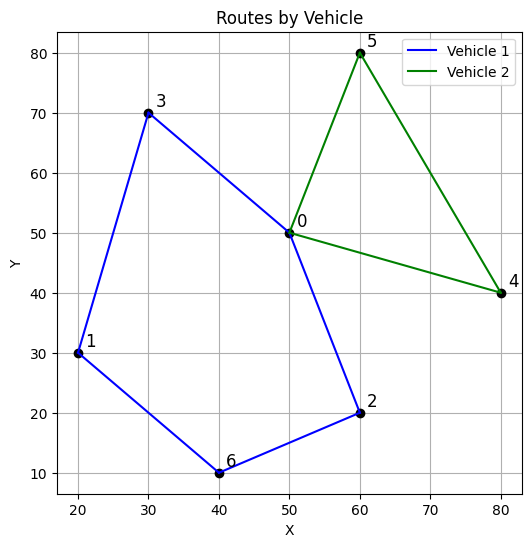

In [4]:
# Retrieve the solutions
routes = {k: [] for k in vehicles}
vals = m.getAttr('X', x)

# Reconstruct routes for each vehicle
for k in vehicles:
    current = 0
    route = [0]
    while True:
        for j in nodes:
            if j != current and vals[current, j, k] > 0.5:
                route.append(j)
                current = j
                break
        if current == 0:
            break
    routes[k] = route

# Function to plot the routes
def plot_routes(locations, routes, title="Routes by Vehicle"):
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    plt.figure(figsize=(6, 6))
    for i in locations:
        x, y = locations[i]
        plt.plot(x, y, 'ko')
        plt.text(x + 1, y + 1, str(i), fontsize=12)

    for k, route in routes.items():
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            x_coords = [locations[a][0], locations[b][0]]
            y_coords = [locations[a][1], locations[b][1]]
            plt.plot(
                x_coords, y_coords, '-',
                color=colors[k % len(colors)],
                label=f'Vehicle {k}' if i == 0 else ""
            )

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot
plot_routes(locations, routes)


In [5]:
import random
import itertools

def generate_cvrp_instance(num_customers=15, num_vehicles=3, vehicle_capacity=35, seed=42):
    random.seed(seed)

    # Create nodes (0 = depot)
    locations = {0: (random.randint(40, 60), random.randint(40, 60))}  # centered depot
    for i in range(1, num_customers + 1):
        locations[i] = (random.randint(0, 100), random.randint(0, 100))

    # Create random demands (customers only)
    demand = {0: 0}
    total_demand = 0
    for j in range(1, num_customers + 1):
        d = random.randint(5, 7)
        demand[j] = d
        total_demand += d

    # Ensure that total vehicle capacity is sufficient
    total_capacity = num_vehicles * vehicle_capacity
    assert total_capacity >= total_demand, (
        f"Insufficient capacity: total demand = {total_demand}, available capacity = {total_capacity}"
    )

    # Compute Euclidean distances
    nodes = list(locations.keys())
    # dist = {
    #     (i, j): round(((locations[i][0] - locations[j][0]) ** 2 +
    #                    (locations[i][1] - locations[j][1]) ** 2) ** 0.5)
    #     for i, j in itertools.permutations(nodes, 2)
    # }

    dist = {
        (i, j): math.floor(((locations[i][0] - locations[j][0]) ** 2 +
                       (locations[i][1] - locations[j][1]) ** 2) ** 0.5)
        for i, j in itertools.permutations(nodes, 2)
    }

    # Customers and vehicles
    customers = [i for i in nodes if i != 0]
    vehicles = list(range(1, num_vehicles + 1))

    return locations, demand, dist, customers, vehicles, vehicle_capacity

In [6]:
locations, demand, dist, customers, vehicles, Q = generate_cvrp_instance(seed= 42)

In [7]:
# Model
m = gp.Model("CVRP")

# Update number of ndoes
nodes = list(locations.keys())

# Binary variables: x[i,j,k] = 1 if vehicle k travels from i to j
x = m.addVars(dist.keys(), vehicles, vtype=GRB.BINARY, name="x")

# Accumulated load variables at each node for each vehicle
u = m.addVars(nodes, vehicles, vtype=GRB.CONTINUOUS, name="u")

# Objective: minimize total distance
m.setObjective(
    gp.quicksum(dist[i, j] * x[i, j, k] for i, j in dist for k in vehicles),
    GRB.MINIMIZE
)

# Each customer is visited exactly once
for j in customers:
    m.addConstr(gp.quicksum(x[i, j, k] for i in nodes if i != j for k in vehicles) == 1)

# Flow conservation for each vehicle
for k in vehicles:
    for h in nodes:
        m.addConstr(
            gp.quicksum(x[i, h, k] for i in nodes if i != h) ==
            gp.quicksum(x[h, j, k] for j in nodes if j != h)
        )

# Capacity constraints (MTZ-like)
for k in vehicles:
    for i, j in itertools.permutations(customers, 2):
        m.addConstr(u[i, k] - u[j, k] + demand[j] * x[i, j, k] <= Q * (1 - x[i, j, k]))

    for j in customers:
        m.addConstr(u[j, k] >= demand[j])
        m.addConstr(u[j, k] <= Q)

# Departure from and return to the depot
for k in vehicles:
    m.addConstr(gp.quicksum(x[0, j, k] for j in customers) <= 1)
    m.addConstr(gp.quicksum(x[j, 0, k] for j in customers) <= 1)

m.write("cvrp.lp")
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 789 rows, 768 columns and 4185 nonzeros (Min)
Model fingerprint: 0x5a50ad58
Model has 720 linear objective coefficients
Variable types: 48 continuous, 720 integer (720 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [1e+01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01]

Presolve removed 90 rows and 3 columns
Presolve time: 0.09s
Presolved: 699 rows, 765 columns, 8195 nonzeros
Variable types: 45 continuous, 720 integer (720 binary)

Root relaxation: objective 3.130000e+02, 97 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

  

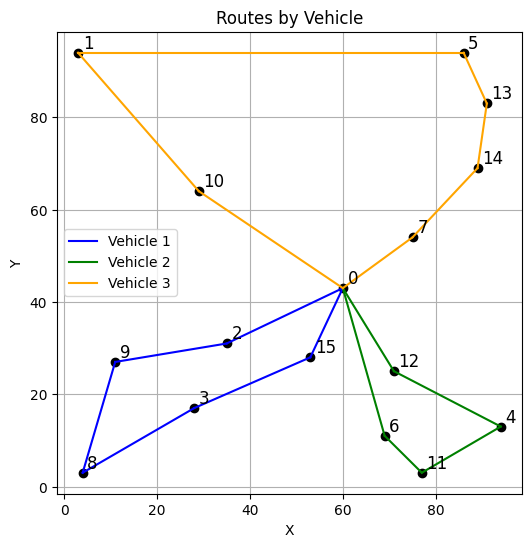

In [8]:
# Retrieve the solutions
routes = {k: [] for k in vehicles}
vals = m.getAttr('X', x)

# Reconstruct routes for each vehicle
for k in vehicles:
    current = 0
    route = [0]
    while True:
        for j in nodes:
            if j != current and vals[current, j, k] > 0.5:
                route.append(j)
                current = j
                break
        if current == 0:
            break
    routes[k] = route

# Function to plot the routes
def plot_routes(locations, routes, title="Routes by Vehicle"):
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    plt.figure(figsize=(6, 6))
    for i in locations:
        x, y = locations[i]
        plt.plot(x, y, 'ko')
        plt.text(x + 1, y + 1, str(i), fontsize=12)

    for k, route in routes.items():
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            x_coords = [locations[a][0], locations[b][0]]
            y_coords = [locations[a][1], locations[b][1]]
            plt.plot(
                x_coords, y_coords, '-',
                color=colors[k % len(colors)],
                label=f'Vehicle {k}' if i == 0 else ""
            )

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot
plot_routes(locations, routes)